In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('ggplot')

In [2]:
def load_data(path):
    return pd.read_csv(path)

df = load_data('titanic_disaster.csv')

df.head(10)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C


In [3]:
print(df.isnull().sum())

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


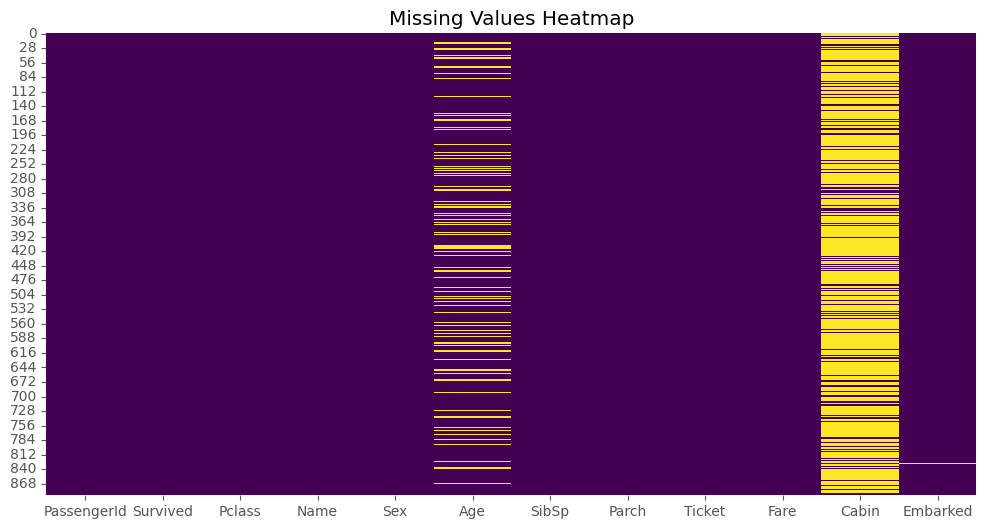

In [4]:
plt.figure(figsize=(12,6))

sns.heatmap(
    df.isnull(),
    cbar=False,
    cmap='viridis'
)

plt.title("Missing Values Heatmap")

plt.show()

In [5]:
df[['secondName','firstName']] = df['Name'].str.split(',', expand=True)

df.drop(columns='Name', inplace=True)

df.head()

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,secondName,firstName
0,1,0,3,male,22.0,1,0,A/5 21171,7.2500,NaN,S,Braund,Mr. Owen Harris
1,2,1,1,female,38.0,1,0,PC 17599,71.2833,C85,C,Cumings,Mrs. John Bradley (Florence Briggs Thayer)
2,3,1,3,female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,Heikkinen,Miss. Laina
3,4,1,1,female,35.0,1,0,113803,53.1000,C123,S,Futrelle,Mrs. Jacques Heath (Lily May Peel)
4,5,0,3,male,35.0,0,0,373450,8.0500,NaN,S,Allen,Mr. William Henry


In [6]:
df['Sex'] = df['Sex'].replace({
    'male':'M',
    'female':'F'
})

df.head()

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,secondName,firstName
0,1,0,3,M,22.0,1,0,A/5 21171,7.2500,NaN,S,Braund,Mr. Owen Harris
1,2,1,1,F,38.0,1,0,PC 17599,71.2833,C85,C,Cumings,Mrs. John Bradley (Florence Briggs Thayer)
2,3,1,3,F,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,Heikkinen,Miss. Laina
3,4,1,1,F,35.0,1,0,113803,53.1000,C123,S,Futrelle,Mrs. Jacques Heath (Lily May Peel)
4,5,0,3,M,35.0,0,0,373450,8.0500,NaN,S,Allen,Mr. William Henry


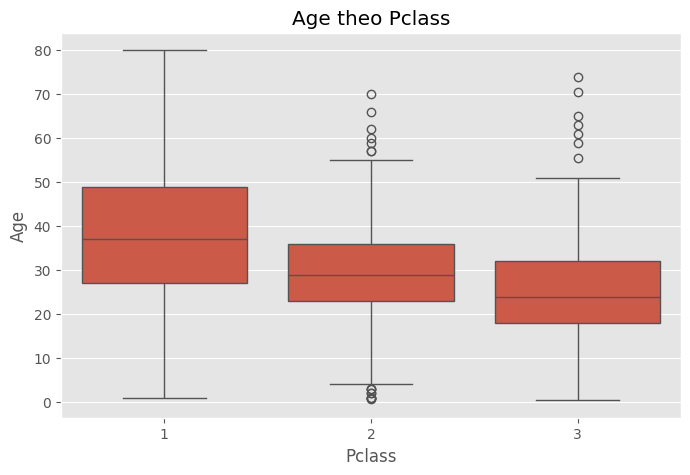

In [7]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x='Pclass',
    y='Age',
    data=df
)

plt.title("Age theo Pclass")

plt.show()

In [8]:
df['Age'] = df.groupby('Pclass')['Age'].transform(
    lambda x: x.fillna(x.mean())
)

df['Age'].isnull().sum()

np.int64(0)

In [9]:
print(df.isnull().sum())

PassengerId      0
Survived         0
Pclass           0
Sex              0
Age              0
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
secondName       0
firstName        0
dtype: int64


In [10]:
df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)

print(df['Embarked'].isnull().sum())

0


/tmp/ipykernel_757/212115921.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)


In [11]:
df['Cabin'] = df['Cabin'].fillna('Unknown')

df['CabinClass'] = df['Cabin'].str[0]

df[['Cabin','CabinClass']].head()

,Cabin,CabinClass
0,Unknown,U
1,C85,C
2,Unknown,U
3,C123,C
4,Unknown,U


In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 14 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Sex          891 non-null    object 
 4   Age          891 non-null    float64
 5   SibSp        891 non-null    int64  
 6   Parch        891 non-null    int64  
 7   Ticket       891 non-null    object 
 8   Fare         891 non-null    float64
 9   Cabin        891 non-null    object 
 10  Embarked     891 non-null    object 
 11  secondName   891 non-null    object 
 12  firstName    891 non-null    object 
 13  CabinClass   891 non-null    object 
dtypes: float64(2), int64(5), object(7)
memory usage: 97.6+ KB


In [13]:
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1

df[['SibSp','Parch','FamilySize']].head()

,SibSp,Parch,FamilySize
0,1,0,2
1,1,0,2
2,0,0,1
3,1,0,2
4,0,0,1


In [14]:
df['IsAlone'] = np.where(df['FamilySize']==1,1,0)

df[['FamilySize','IsAlone']].head()

,FamilySize,IsAlone
0,2,0
1,2,0
2,1,1
3,2,0
4,1,1


In [15]:
bins=[0,12,18,35,60,100]

labels=[
    'Child',
    'Teen',
    'Young Adult',
    'Adult',
    'Senior'
]

df['AgeGroup']=pd.cut(
    df['Age'],
    bins=bins,
    labels=labels
)

df[['Age','AgeGroup']].head()

,Age,AgeGroup
0,22.0,Young Adult
1,38.0,Adult
2,26.0,Young Adult
3,35.0,Young Adult
4,35.0,Young Adult


In [16]:
df['FareGroup']=pd.qcut(
    df['Fare'],
    q=4,
    labels=[
        'Low',
        'Medium',
        'High',
        'Very High'
    ]
)

df[['Fare','FareGroup']].head()

,Fare,FareGroup
0,7.2500,Low
1,71.2833,Very High
2,7.9250,Medium
3,53.1000,Very High
4,8.0500,Medium


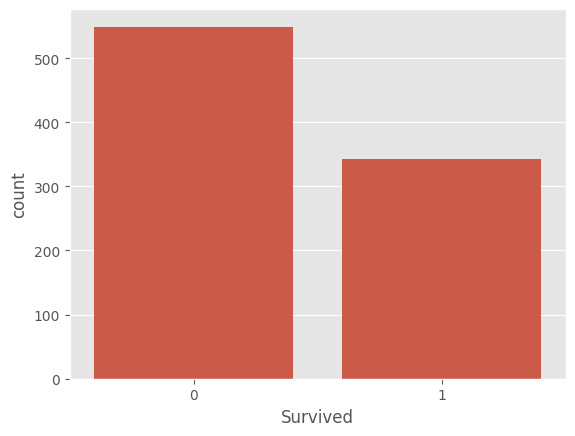

In [17]:
sns.countplot(
    x='Survived',
    data=df
)

plt.show()

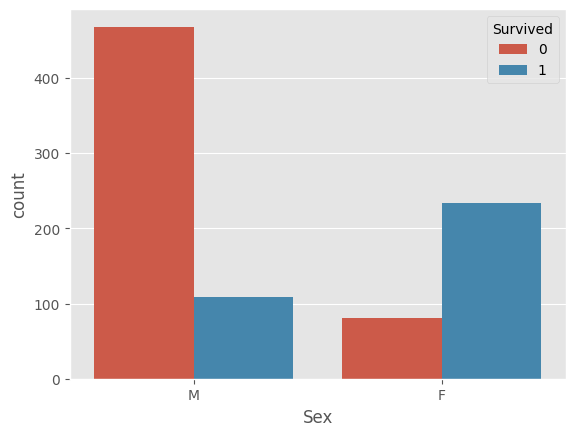

In [18]:
sns.countplot(
    x='Sex',
    hue='Survived',
    data=df
)

plt.show()

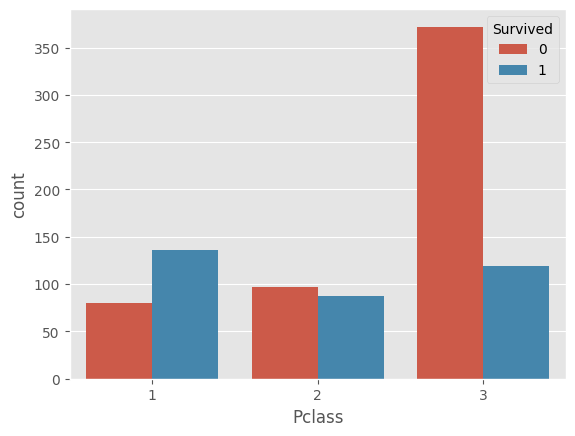

In [19]:
sns.countplot(
    x='Pclass',
    hue='Survived',
    data=df
)

plt.show()

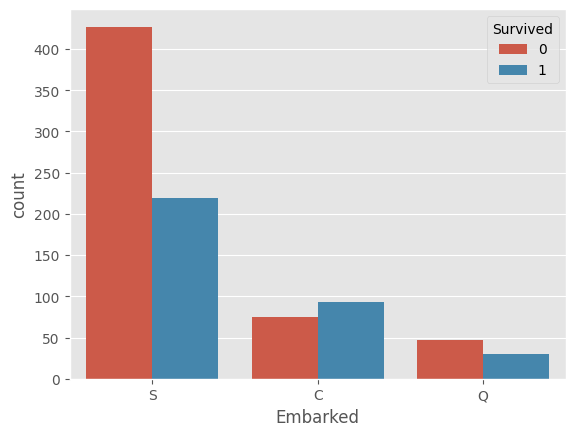

In [20]:
sns.countplot(
    x='Embarked',
    hue='Survived',
    data=df
)

plt.show()

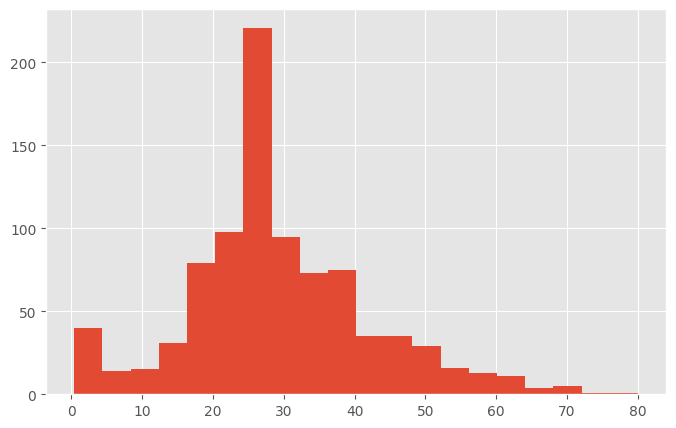

In [21]:
plt.figure(figsize=(8,5))

plt.hist(df['Age'],bins=20)

plt.show()

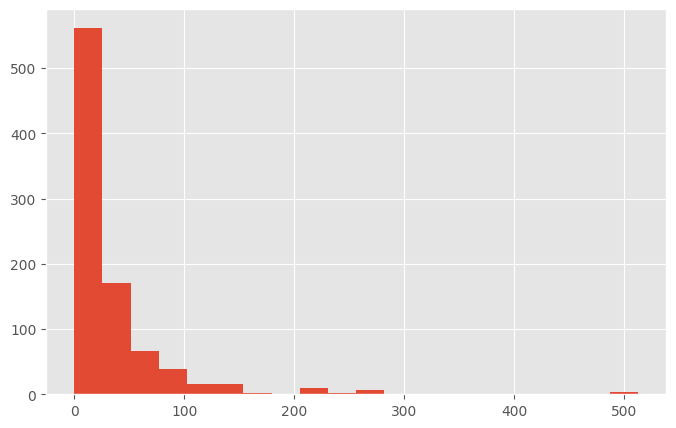

In [22]:
plt.figure(figsize=(8,5))

plt.hist(df['Fare'],bins=20)

plt.show()

In [23]:
df=pd.get_dummies(
    df,
    columns=[
        'Sex',
        'Embarked',
        'CabinClass',
        'AgeGroup',
        'FareGroup'
    ],
    drop_first=True
)

In [24]:
df=df.drop(
    columns=[
        'Ticket',
        'Cabin',
        'PassengerId',
        'firstName',
        'secondName'
    ]
)

df.head()

,Survived,Pclass,Age,SibSp,Parch,Fare,FamilySize,IsAlone,Sex_M,Embarked_Q,...,CabinClass_G,CabinClass_T,CabinClass_U,AgeGroup_Teen,AgeGroup_Young Adult,AgeGroup_Adult,AgeGroup_Senior,FareGroup_Medium,FareGroup_High,FareGroup_Very High
0,0,3,22.0,1,0,7.2500,2,0,True,False,...,False,False,True,False,True,False,False,False,False,False
1,1,1,38.0,1,0,71.2833,2,0,False,False,...,False,False,False,False,False,True,False,False,False,True
2,1,3,26.0,0,0,7.9250,1,1,False,False,...,False,False,True,False,True,False,False,True,False,False
3,1,1,35.0,1,0,53.1000,2,0,False,False,...,False,False,False,False,True,False,False,False,False,True
4,0,3,35.0,0,0,8.0500,1,1,True,False,...,False,False,True,False,True,False,False,True,False,False


In [25]:
df.to_csv(
    'processed_titanic.csv',
    index=False
)

print("Đã lưu file processed_titanic.csv")

Đã lưu file processed_titanic.csv
